## 11.07节练习参考答案

## 环境准备

In [ ]:
import os, sys
os.environ["TILE_FWK_DEVICE_ID"] = "0"
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
# 本 notebook 位于 answers/ 子目录下，数据缓存在 ../data（与主 notebook 共享）。
# 切到章节根目录，避免 torchvision 因找不到已有数据而重新从 S3（法兰克福）
# 慢速下载 Fashion-MNIST。
if os.path.isdir("../src"):
    os.chdir("..")

# 固定 PyPTO 编译缓存目录（与 11.08/11.11 主 notebook 共用 ../ptile_cache）：
# 内核/Jupyter 重启后无需从零重新编译算子。
# PTO_TILE_LIB_CODE_PATH 目录还必须包含 include/pto（pto-isa 头文件），
# 否则算子编译时报 PTO_ISA_NOT_FOUND；用软链指向 CANN 自带的头文件即可。
os.environ["PTO_TILE_LIB_CODE_PATH"] = os.path.abspath("../ptile_cache")
_pto_lib = os.environ["PTO_TILE_LIB_CODE_PATH"]
os.makedirs(os.path.join(_pto_lib, "include"), exist_ok=True)
_pto_isa_link = os.path.join(_pto_lib, "include", "pto")
if not os.path.exists(_pto_isa_link):
    import glob
    _isa_candidates = glob.glob(os.path.expanduser(
        "~/Ascend/cann-*/aarch64-linux/include/pto"))
    if _isa_candidates:
        os.symlink(os.path.abspath(_isa_candidates[0]), _pto_isa_link)
    else:
        raise RuntimeError("未找到 pto-isa 头文件目录（~/Ascend/cann-*/aarch64-linux/include/pto）")

%matplotlib inline
import pypto
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch_npu
import torchvision
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
import math

from src.utils import *
from src.pto_layers import PyPTOLinear, PyPTOReLU
from src.PyPTOConv2DModule import PyPTOConv2d
from src.PyPTOPoolModule import PyPTOMaxPool2d, PyPTOAvgPool2d

本节的解答思路参考了 [《动手学深度学习》习题解答](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/ch11/ch11)，并在此基础上补充了 PyPTO 的实现。

### 练习11.7.1
证明对于正交矩阵$\mathbf{U}$和向量$\mathbf{c}$，以下等式成立：$\|\mathbf{c} - \mathbf{\delta}\|_2 = \|\mathbf{U} \mathbf{c} - \mathbf{U} \mathbf{\delta}\|_2$。为什么这意味着在变量的正交变化之后，扰动的程度不会改变？

**解答：**

首先证明该等式成立：

等式左侧可以展开为：
$$
\| \boldsymbol{c}-\boldsymbol{\delta}\|^2 = (\boldsymbol{c}-\boldsymbol{\delta})^\mathrm{T}(\boldsymbol{c}-\boldsymbol{\delta})=\boldsymbol{c}^\mathrm{T}\boldsymbol{c}-2\boldsymbol{c}^\mathrm{T}\boldsymbol{\delta}+\boldsymbol{\delta}^\mathrm{T}\boldsymbol{\delta}
$$

等式右侧可以展开为：
$$
\| \boldsymbol{U}\boldsymbol{c}-\boldsymbol{U}\boldsymbol{\delta}\|^2 = (\boldsymbol{U}\boldsymbol{c}-\boldsymbol{U}\boldsymbol{\delta})^\mathrm{T}(\boldsymbol{U}\boldsymbol{c}-\boldsymbol{U}\boldsymbol{\delta})=\boldsymbol{c}^\mathrm{T}\boldsymbol{U}^\mathrm{T}\boldsymbol{U}\boldsymbol{c}-2\boldsymbol{c}^\mathrm{T}\boldsymbol{U}^\mathrm{T}\boldsymbol{U}\boldsymbol{\delta}+\boldsymbol{\delta}^\mathrm{T}\boldsymbol{U}^\mathrm{T}\boldsymbol{U}\boldsymbol{\delta}
$$

由于 $\boldsymbol{U}$ 为正交矩阵，即：
$$
\boldsymbol{U}^\mathrm{T}\boldsymbol{U}=\boldsymbol{I}
$$

所以可得：
$$
\boldsymbol{c}^\mathrm{T}\boldsymbol{U}^\mathrm{T}\boldsymbol{U}\boldsymbol{c}=\boldsymbol{c}^\mathrm{T}\boldsymbol{c},\;
\boldsymbol{c}^\mathrm{T}\boldsymbol{U}^\mathrm{T}\boldsymbol{U}\boldsymbol{\delta}=\boldsymbol{c}^\mathrm{T}\boldsymbol{\delta},\;
\boldsymbol{\delta}^\mathrm{T}\boldsymbol{U}^\mathrm{T}\boldsymbol{U}\boldsymbol{\delta}=\boldsymbol{\delta}^\mathrm{T}\boldsymbol{\delta}
$$

带入以上展开式可证：
$$
\| \boldsymbol{c}-\boldsymbol{\delta}\|_2=\|\boldsymbol{U}\boldsymbol{c}-\boldsymbol{U}\boldsymbol{\delta}\|_2
$$

为什么这意味着在变量的正交变化之后，扰动的程度不会改变：

我们可以将扰动的程度理解为变换之后的向量与原向量的距离，即假设我们有扰动变量 $\boldsymbol{\delta}$，那么扰动的程度即为原变量 $\boldsymbol{x}$ 与扰动后变量 $\boldsymbol{x}+\boldsymbol{\delta}$ 的距离，即 $\|\boldsymbol{x}-(\boldsymbol{x}+\boldsymbol{\delta})\|_2$，而我们已经证明，乘以正交矩阵之后该距离没有变化，因此扰动的程度没有改变。

### 练习11.7.2
尝试对函数$f(\mathbf{x}) = 0.1 x_1^2 + 2 x_2^2$、以及它旋转45度后的函数即$f(\mathbf{x}) = 0.1 (x_1 + x_2)^2 + 2 (x_1 - x_2)^2$使用AdaGrad算法。它的表现会不同吗？

**解答：**

我们首先对 $f(\boldsymbol{x})=0.1x_1^2+2x_2^2$ 使用 AdaGrad 算法：

epoch 20, x1: -2.382563, x2: -0.158591


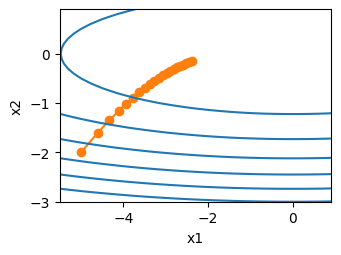

In [3]:
def adagrad_2d(x1, x2, s1, s2):
    eps = 1e-6
    g1, g2 = 0.2 * x1, 4 * x2
    s1 += g1 ** 2
    s2 += g2 ** 2
    x1 -= eta / math.sqrt(s1 + eps) * g1
    x2 -= eta / math.sqrt(s2 + eps) * g2
    return x1, x2, s1, s2

def f_2d(x1, x2):
    return 0.1 * x1 ** 2 + 2 * x2 ** 2

eta = 0.4
show_trace_2d(f_2d, train_2d(adagrad_2d))

接着对旋转后的函数 $f(\boldsymbol{x})=0.1(x_1+x_2)^2+2(x_1-x_2)^2$ 使用 AdaGrad 算法：

epoch 20, x1: -3.180865, x2: -3.062780


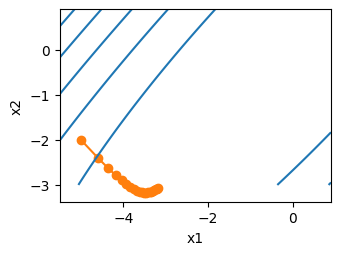

In [4]:
def adagrad_2d(x1, x2, s1, s2):
    eps = 1e-6
    g1, g2 = 4.2 * x1 - 3.8 * x2, 4.2 * x2 - 3.8 * x1
    s1 += g1 ** 2
    s2 += g2 ** 2
    x1 -= eta / math.sqrt(s1 + eps) * g1
    x2 -= eta / math.sqrt(s2 + eps) * g2
    return x1, x2, s1, s2

def f_2d_2(x1, x2):
    return 0.1 * (x1 + x2) ** 2 + 2 * (x1 - x2) ** 2

eta = 0.4
show_trace_2d(f_2d_2, train_2d(adagrad_2d))

可以看到，两者的步长都是逐渐衰减的。

### 练习11.7.3
证明[格什戈林圆盘定理](https://en.wikipedia.org/wiki/Gershgorin_circle_theorem)，其中提到，矩阵$\mathbf{M}$的特征值$\lambda_i$在至少一个$j$的选项中满足$|\lambda_i - \mathbf{M}_{jj}| \leq \sum_{k \neq j} |\mathbf{M}_{jk}|$的要求。

**解答：**

设 $\boldsymbol{\zeta}\ne\boldsymbol{0}$ 为 $M$ 对应特征值 $\lambda$ 的特征向量，$M\boldsymbol{\zeta}=\lambda\boldsymbol{\zeta}$。取 $j$ 使 $|\zeta_j|=\max_k|\zeta_k|$（$\zeta_j\ne0$）。由第 $j$ 个分量方程

$$\sum_{k}M_{jk}\zeta_k=\lambda\zeta_j\quad\Longrightarrow\quad(\lambda-M_{jj})\zeta_j=\sum_{k\ne j}M_{jk}\zeta_k.$$

取绝对值并用 $|\zeta_k|\le|\zeta_j|$：

$$|\lambda-M_{jj}|\,|\zeta_j|\le\sum_{k\ne j}|M_{jk}|\,|\zeta_k|\le\Big(\sum_{k\ne j}|M_{jk}|\Big)|\zeta_j|.$$

两边除以 $|\zeta_j|\ne0$ 得 $|\lambda-M_{jj}|\le\sum_{k\ne j}|M_{jk}|$，即 $\lambda$ 落在以 $M_{jj}$ 为心、行非对角元绝对值之和为半径的圆盘内。

### 练习11.7.4
关于对角线预处理矩阵$\mathrm{diag}^{-\frac{1}{2}}(\mathbf{M}) \mathbf{M} \mathrm{diag}^{-\frac{1}{2}}(\mathbf{M})$的特征值，格什戈林的定理告诉了我们什么？

**解答：**

设 $D_m=\mathrm{diag}(M)$（$M$ 对角部分，假定对角元非零），预处理矩阵

$$D=D_m^{-1/2}MD_m^{-1/2},\qquad D_{ij}=\frac{M_{ij}}{\sqrt{M_{ii}M_{jj}}}.$$

其对角元 $D_{ii}=1$，即对角元被归一化为 $1$。由 Gershgorin 定理，$D$ 的特征值落在以 $1$ 为心、$R_i=\sum_{j\ne i}\dfrac{|M_{ij}|}{\sqrt{M_{ii}M_{jj}}}$ 为半径的圆盘并集内。

注意 $D$ 是 $M$ 的合同变换（非相似变换），保持惯性（特征值符号分布）但**不**保持特征值，故一般 $\mu\ne\lambda$。

In [14]:
def accuracy(y_hat, y):
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

def try_gpu(i=0):
    if torch.npu.is_available():
        return torch.device(f"npu:{i}")
    return torch.device("cpu")

# 数据加载直接使用 src.utils 的 load_data_fashion_mnist（drop_last=True）：
# 丢弃不满的尾批，使训练/评估全程只有 bs=256 一种 batch 形状，
# 避免 PyPTO kernel 因尾批形状（96/16）触发新一轮漫长的 JIT 编译。

### 练习11.7.5
尝试对适当的深度网络使用AdaGrad算法，例如，[06.06_lenet](../06_pypto_pypto_convolutional_networks/06.06_lenet.ipynb)中应用于Fashion-MNIST的深度网络。

**解答：**

In [15]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10))

batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size=batch_size)

def evaluate_accuracy_gpu(net, data_iter, device=None):
    """使用GPU计算模型在数据集上的精度"""
    if isinstance(net, nn.Module):
        net.eval()  # 设置为评估模式
        if not device:
            device = next(iter(net.parameters())).device
    # 正确预测的数量，总预测的数量
    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, list):
                # BERT微调所需的（之后将介绍）
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]


def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    """用GPU训练模型(在第六章定义)"""
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = Timer(), len(train_iter)
    for epoch in range(num_epochs):
        # 训练损失之和，训练准确率之和，样本数
        metric = Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')

training on npu:0


loss 0.365, train acc 0.866, test acc 0.850
92248.1 examples/sec on npu:0


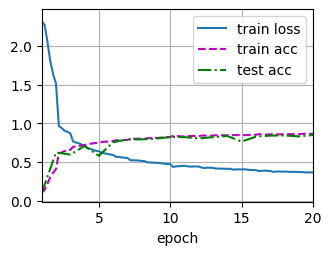

In [16]:
lr, num_epochs = 0.9, 20
train_ch6(net, train_iter, test_iter, num_epochs, lr, try_gpu())

接着，我们将 SGD 优化器替换为 AdaGrad 优化器：

In [8]:
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    """用GPU训练模型(在第六章定义)"""
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('training on', device)
    net.to(device)
    optimizer = torch.optim.Adagrad(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = Timer(), len(train_iter)
    for epoch in range(num_epochs):
        # 训练损失之和，训练准确率之和，样本数
        metric = Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')

training on npu:0
loss 2.323, train acc 0.100, test acc 0.100
82218.7 examples/sec on npu:0


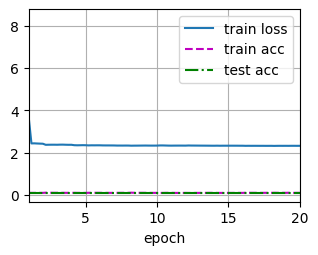

In [9]:
lr, num_epochs = 0.9, 20
train_ch6(net, train_iter, test_iter, num_epochs, lr, try_gpu())

可以看出，使用 AdaGrad 算法在一开始 loss 下降得更陡峭、迅速，但随后 loss 下降速度开始衰减，显著慢于使用 SGD 算法，以及 20 个 epoch 迭代之后我们对比发现，虽然 AdaGrad 算法在前3个 epoch 就实现了 loss 的骤降，但最终并没能实现稳定的收敛。

**PyPTO 版**

In [10]:
net = nn.Sequential(
    PyPTOConv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
    PyPTOAvgPool2d(kernel_size=2, stride=2),
    PyPTOConv2d(6, 16, kernel_size=5), nn.Sigmoid(),
    PyPTOAvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    PyPTOLinear(16 * 5 * 5, 120), nn.Sigmoid(),
    PyPTOLinear(120, 84), nn.Sigmoid(),
    PyPTOLinear(84, 10))

batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size=batch_size)

def evaluate_accuracy_gpu(net, data_iter, device=None):
    """使用GPU计算模型在数据集上的精度"""
    if isinstance(net, nn.Module):
        net.eval()  # 设置为评估模式
        if not device:
            device = next(iter(net.parameters())).device
    # 正确预测的数量，总预测的数量
    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, list):
                # BERT微调所需的（之后将介绍）
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]


def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    """用GPU训练模型(在第六章定义)"""
    def init_weights(m):
        if type(m) == PyPTOLinear or type(m) == PyPTOConv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = Timer(), len(train_iter)
    for epoch in range(num_epochs):
        # 训练损失之和，训练准确率之和，样本数
        metric = Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')

In [ ]:
import time

# PyPTO 自定义算子首次调用时需要 JIT 编译，每种新的 batch 形状耗时约 1~2 分钟，
# 期间 notebook 看似“卡住”（无输出），属正常现象，请耐心等待、切勿中断内核。
# 数据加载已启用 drop_last=True，训练/评估全程只有 bs=256 一种 batch 形状，
# 因此只需预热该形状（前向+反向）即可；配合 ../ptile_cache 编译缓存，
# 重启内核后再次运行时本次预热通常只需数秒：
device = try_gpu()
net.to(device)
loss_fn = nn.CrossEntropyLoss()
t0 = time.time()
X = torch.randn(256, 1, 28, 28, device=device)
y = torch.randint(0, 10, (256,), device=device)
l = loss_fn(net(X), y)
l.backward()
net.zero_grad()  # 清除预热引入的梯度，避免影响首轮训练
print(f'warm up bs=256: {time.time() - t0:.1f}s', flush=True)

training on npu:0
loss 0.361, train acc 0.867, test acc 0.843
4991.3 examples/sec on npu:0


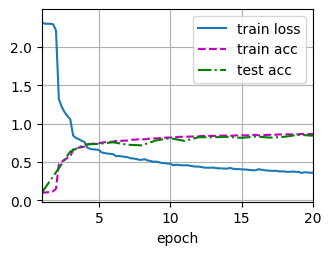

In [11]:
lr, num_epochs = 0.9, 20
train_ch6(net, train_iter, test_iter, num_epochs, lr, try_gpu())

接着，我们将 SGD 优化器替换为 AdaGrad 优化器：

In [12]:
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    """用GPU训练模型(在第六章定义)"""
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('training on', device)
    net.to(device)
    optimizer = torch.optim.Adagrad(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = Timer(), len(train_iter)
    for epoch in range(num_epochs):
        # 训练损失之和，训练准确率之和，样本数
        metric = Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')

training on npu:0
loss 2.326, train acc 0.097, test acc 0.100
21477.8 examples/sec on npu:0


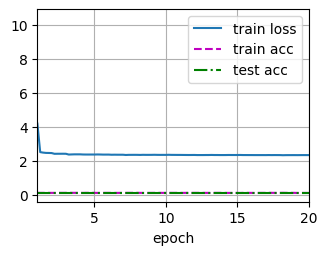

In [13]:
lr, num_epochs = 0.9, 20
train_ch6(net, train_iter, test_iter, num_epochs, lr, try_gpu())

可以看出，使用 AdaGrad 算法在一开始 loss 下降得更陡峭、迅速，但随后 loss 下降速度开始衰减，显著慢于使用 SGD 算法，以及 20 个 epoch 迭代之后我们对比发现，虽然 AdaGrad 算法在前3个 epoch 就实现了 loss 的骤降，但最终并没能实现稳定的收敛。

### 练习11.7.6
要如何修改AdaGrad算法，才能使其在学习率方面的衰减不那么激进？

**解答：**

AdaGrad 算法之所以在学习率方面的衰减会越发激进，是因为 AdaGrad 算法会累积历史梯度，造成后续学习率很小，权值无法得到有效更新。

为改进这一问题，有学者提出了 RMSProp 算法，该算法增加了一个衰减系数来控制历史信息的获取，即我们在下一章将要学习的算法。